# Visualisation de données 2D

In [2]:
import matplotlib.pyplot as plt
import numpy as np

On ne va pas utiliser le mode automatique de matplotlib (`plt.ion()`)

- Changer la taille par défaut des figures matplotlib

In [3]:
plt.rcParams["figure.figsize"] = (8, 3)

## `plt.plot`

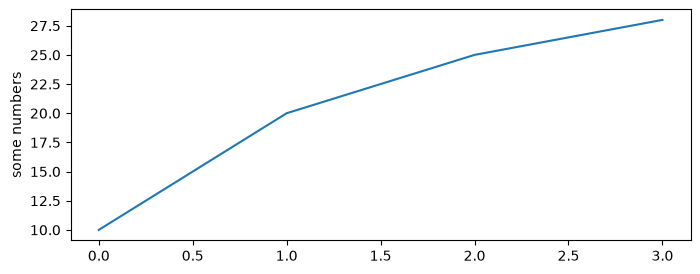

In [4]:
# si je ne donne qu'une seule liste à plot alors ce sont les Y
plt.plot([10, 20, 25, 28])
# on peut aussi facilement ajouter une légende sur l'axe des y
plt.ylabel("some numbers")
plt.show()

On peut changer le style utilisé par plot pour tracer ; ce style est spécifié sous la forme d’une chaîne de caractères, par défaut `b-`, qui signifie une ligne bleue (b pour bleu, et `-` pour ligne). Ici on va préciser à la place `ro`, `r` qui signifie rouge et `o` qui signifie cercle.

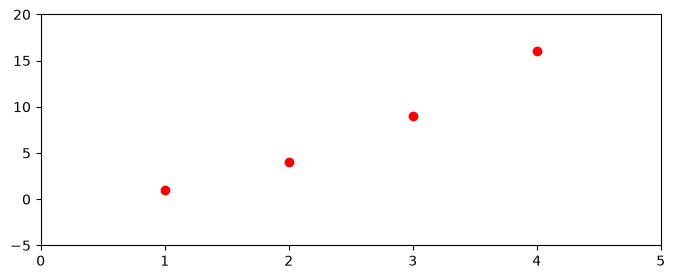

In [5]:
# mais le plus souvent on passe à plot une liste de X ET de Y
plt.plot([1, 2, 3, 4, 5], [1, 4, 9, 16, 25], 'ro')
# ici on veut dire d'utiliser
# pour l'axe des X : entre 0 et 5
# pour l'axe des Y : entre -5 et 20
plt.axis([0, 5, -5, 20])
plt.show()


On peut très simplement dessiner plusieurs fonctions dans la même zone

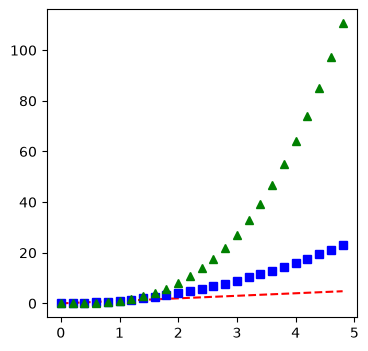

In [6]:
# changer la taille d'une figure
plt.figure(figsize=(4, 4))

# échantillon de points entre 0 et 5 espacés de 0.2
t = np.arange(0., 5., 0.2)

# appliquer plusieurs styles de ligne
plt.plot(t, t, 'r--')
plt.plot(t, t**2, 'bs')
plt.plot(t, t**3, 'g^')
plt.show()


## Subplot

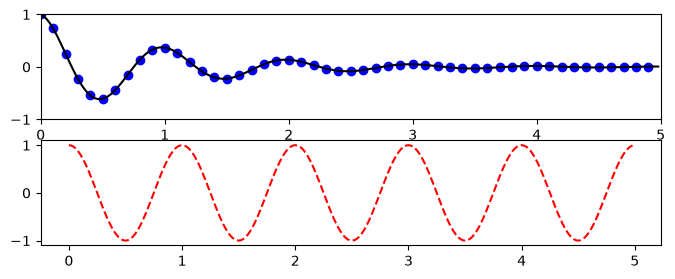

In [53]:
def f(t) -> float:
    """
    Fonction exponentielle amortie
    
    :param t: le temps
    :return: la valeur de la fonction
    """
    return np.exp(-t) * np.cos(2*np.pi*t)

t1 = np.arange(0.0, 5.0, 0.1)
t2 = np.arange(0.0, 5.0, 0.02)

# cet appel n'est pas nécessaire
plt.figure(1)
# on crée un 'subplot'
plt.subplot(211)
# le fonctionnement de matplotlib est dit 'stateful'
# par défaut on dessine dans le dernier objet créé.
# 'k' signifie la couleur noir
plt.axis([0, 5, -1, 1])
plt.plot(t1, f(t1), 'bo', t2, f(t2), 'k')

# une deuxième subplot
plt.subplot(212)
plt.plot(t2, np.cos(2*np.pi*t2), 'r--')
plt.show()

`plt.subplot(211)` est par ailleurs juste un raccourci pour `plt.subplot(2, 1, 1)` qui veut dire, qu’on veut créer un quadrillage de 2 lignes de 1 colonne, et que le subplot va occuper le 1er emplacement.

Lettre |français  |anglais
-------|----------|-------
b	   |Bleu	  |Blue
g	   |Vert	  |Green
r	   |Rouge	  |Red
c	   |Cyan	  |Cyan
m	   |Magenta   |Magenta
y	   |Jaune	  |Yellow
k	   |Noir	  |Black
w	   |Blanc	  |White


On peut créer plusieurs figures, et plusieurs subplots dans chaque figure. Ceci illustre encore mieux cette notion de statefulness.

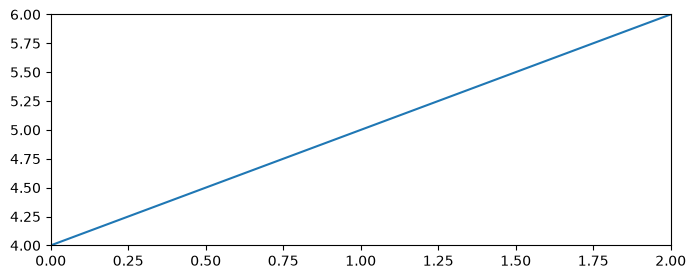

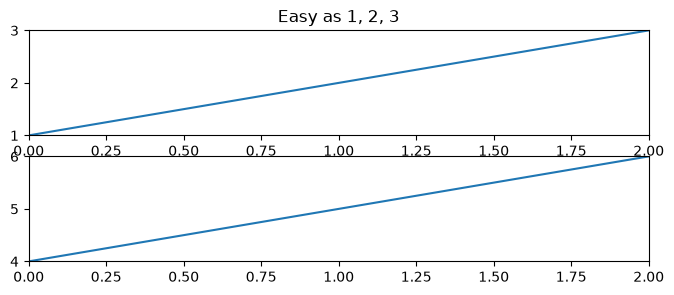

In [8]:
plt.figure(1)
plt.subplot(211)
plt.axis([0, 2, 1, 3])
plt.plot([1, 2, 3])
plt.subplot(212)
plt.axis([0, 2, 4, 6])
plt.plot([4, 5, 6])


plt.figure(2)
plt.axis([0, 2, 4, 6])
plt.plot([4, 5, 6])

plt.figure(1)
plt.subplot(211)
plt.title('Easy as 1, 2, 3')
plt.show()

## Subplots

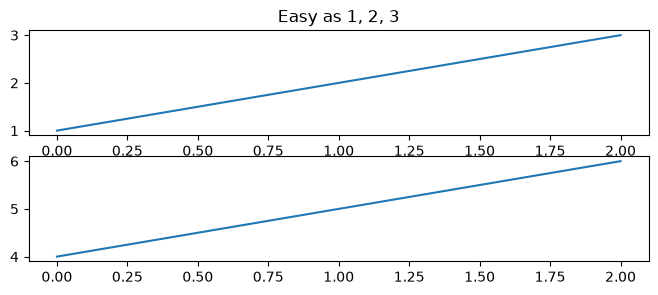

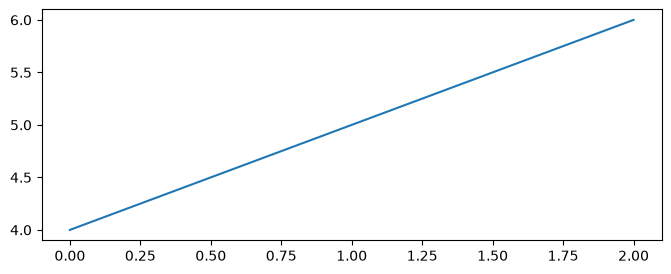

In [21]:
fig1, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot([1, 2, 3])
ax2.plot([4, 5, 6])

fig2, ax3 = plt.subplots(1, 1)
ax3.plot([4, 5, 6])

ax1.set_title('Easy as 1, 2, 3')

plt.show()

## `plt.hist`

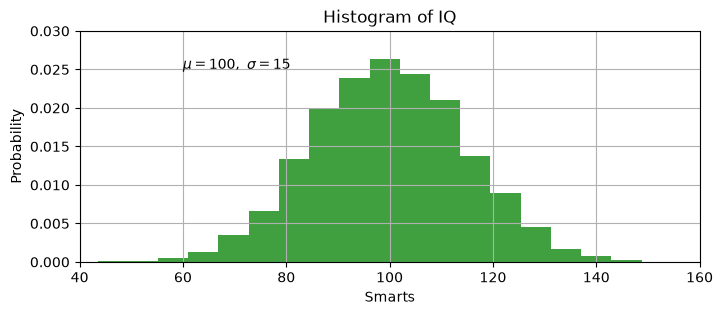

In [60]:
# pour être reproductible, on fixe la graine du générateur aléatoire
np.random.seed(19680801)

mu, sigma = 100, 15
x = mu + sigma * np.random.randn(10000)

# dessine un histogramme et range les valeurs en 20 boites (bins)
n, bins, patches = plt.hist(x, 20, density=1, facecolor='g', alpha=0.75)

plt.xlabel('Smarts')
plt.ylabel('Probability')
plt.title('Histogram of IQ')
plt.text(60, 0.025, r'$\mu=100,\ \sigma=15$')
plt.axis([40, 160, 0, 0.03])
plt.grid(True)
plt.show()

`np.random.seed(19680801)`

Sert à générer des données aléatoires suivant une distribution normale (courbe de Gauss)

- Signification : Initialise le générateur de nombres aléatoires de NumPy avec une "graine" (seed) fixe (ici 19680801).

- Pourquoi ? Cela garantit que le script générera exactement les mêmes nombres pseudo-aléatoires à chaque exécution. C'est indispensable pour rendre vos résultats reproductibles.

- On peut remplacer ce nombre par n'importe quel autre entier (par exemple 42, 0, ou 2026) et le code fonctionnera exactement de la même manière, mais les valeurs aléatoires générées seront différentes.

`mu, sigma = 100, 15`

- Signification : Crée deux variables. mu ($\mu$) représente la moyenne (ici fixée à 100) et sigma ($\sigma$) représente l'écart-type (ici fixé à 15). Ce sont les paramètres classiques d'un QI (Quotient Intellectuel).

`x = mu + sigma * np.random.randn(10000)`

- Signification : Génère un tableau NumPy (x) contenant 10 000 valeurs aléatoires.

- Détail mathématique : np.random.randn(10000) génère 10 000 valeurs selon une loi normale centrée réduite (moyenne = 0, écart-type = 1). En multipliant par sigma et en ajoutant mu, on décale ces données pour qu'elles suivent une loi normale de moyenne 100 et d'écart-type 15. 

> si on utilise `np.random.rand` ou `np.random.randint`,l'histogramme aurait formé un rectangle plat au lieu d'une jolie cloche symétrique.


`n, bins, patches = plt.hist(x, 20, density=1, facecolor='g', alpha=0.75)`

- 20 : Divise l'ensemble des données en 20 intervalles (boîtes ou bins) d'égale largeur.

- density=1 (équivalent à True) : Normalise le graphique. L'axe vertical n'affiche plus le nombre brut d'éléments, mais la densité de probabilité. L'aire totale sous l'histogramme sera égale à 1.

- facecolor='g' : Colore les barres en vert (g pour green).

- alpha=0.75 : Règle la transparence des barres à 75 % (laissant deviner le quadrillage en arrière-plan).

- Les variables retournées :

- n : Un tableau contenant la valeur de la densité pour chacune des 20 barres.

- bins : Un tableau contenant les limites (les frontières) de chaque intervalle.

- patches : Une liste d'objets graphiques représentant chaque barre, utile si l'on veut modifier leur style individuellement plus tard. [4, 5]

`plt.text(60, 0.025, r'$\mu=100,\ \sigma=15$')`

- Signification : Ajoute un texte personnalisé à l'intérieur du graphique aux coordonnées spécifiques X = 60 et Y = 0.025. [11, 12]

- Le r'...' (raw string) : Indique à Python de lire la chaîne de caractères brute, sans interpréter les antislashs \ comme des caractères d'échappement informatiques.

- Les `$...$` (MathText) : Matplotlib utilise une syntaxe proche de LaTeX pour écrire des formules mathématiques. \mu affichera la lettre grecque `$\mu$` et \sigma affichera `$\sigma$`. Le `\` (antislash suivi d'un espace) permet de forcer un espace visible dans le rendu mathématique.


## `plt.scatter`

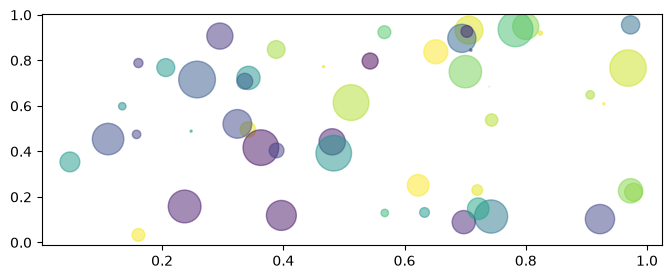

In [38]:
np.random.seed(19680801)

N = 50
x = np.random.rand(N)
y = np.random.rand(N)
colors = np.random.rand(N)

area = np.pi * (15 * np.random.rand(N)) ** 2

plt.scatter(x, y, s=area, c=colors, alpha=0.5)
plt.show()

## `plt.boxplot`

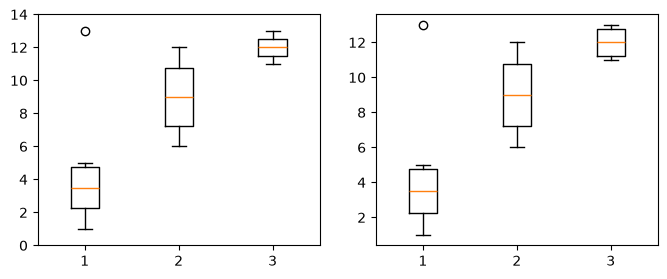

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2)

# on peut passer à boxplot une liste de suites de nombres
# chaque suite donne lieu à une boite à moustache
# ici 3 suites
ax1.boxplot([[1, 2, 3, 4, 5, 13], [6, 7, 8, 10, 11, 12], [11, 12 ,13]])
ax1.set_ylim(0, 14)

# on peut aussi comme toujours lui passer un ndarray numpy
# attention c'est lu dans l'autre sens, ici aussi on a 3 suites de nombres
ax2.boxplot(np.array([[1, 6, 11],
                      [2, 7, 12],
                      [3, 8, 13],
                      [4, 10, 11],
                      [5, 11, 12],
                      [13, 12, 13]]))
plt.show()